In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("car_MSRP.csv")
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP (Manufacturer's suggested retail Price)
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
df.tail()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP (Manufacturer's suggested retail Price)
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920
11913,Lincoln,Zephyr,2006,regular unleaded,221.0,6.0,AUTOMATIC,front wheel drive,4.0,Luxury,Midsize,Sedan,26,17,61,28995


In [4]:
df.dtypes

Make                                             object
Model                                            object
Year                                              int64
Engine Fuel Type                                 object
Engine HP                                       float64
Engine Cylinders                                float64
Transmission Type                                object
Driven_Wheels                                    object
Number of Doors                                 float64
Market Category                                  object
Vehicle Size                                     object
Vehicle Style                                    object
highway MPG                                       int64
city mpg                                          int64
Popularity                                        int64
MSRP (Manufacturer's suggested retail Price)      int64
dtype: object

In [5]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity',
       'MSRP (Manufacturer's suggested retail Price)'],
      dtype='object')

In [6]:
df.isnull().sum()

Make                                               0
Model                                              0
Year                                               0
Engine Fuel Type                                   3
Engine HP                                         69
Engine Cylinders                                  30
Transmission Type                                  0
Driven_Wheels                                      0
Number of Doors                                    6
Market Category                                 3742
Vehicle Size                                       0
Vehicle Style                                      0
highway MPG                                        0
city mpg                                           0
Popularity                                         0
MSRP (Manufacturer's suggested retail Price)       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(715)

In [8]:
df=df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11199 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Make                                          11199 non-null  object 
 1   Model                                         11199 non-null  object 
 2   Year                                          11199 non-null  int64  
 3   Engine Fuel Type                              11196 non-null  object 
 4   Engine HP                                     11130 non-null  float64
 5   Engine Cylinders                              11169 non-null  float64
 6   Transmission Type                             11199 non-null  object 
 7   Driven_Wheels                                 11199 non-null  object 
 8   Number of Doors                               11193 non-null  float64
 9   Market Category                               7823 non-null   obje

In [11]:
x=df.drop("MSRP (Manufacturer's suggested retail Price)",axis=1)
y=df["MSRP (Manufacturer's suggested retail Price)"]

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [14]:
num_cols=x_train.select_dtypes(include=["float64","int64"]).columns
cat_cols=x_train.select_dtypes(include=["object"]).columns

In [15]:
num_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("encoder",StandardScaler())])

In [16]:
cat_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("scalar",OneHotEncoder(handle_unknown="ignore"))])

In [17]:
processor=ColumnTransformer([
    ("num",num_pipe,num_cols),
    ("cat",cat_pipe,cat_cols)])

In [18]:
x_train_transform=processor.fit_transform(x_train)
x_test_transform=processor.transform(x_test)


In [19]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
model=dt.fit(x_train_transform,y_train)

In [20]:
y_pred=model.predict(x_test_transform)

In [21]:
y_train_pred=model.predict(x_train_transform)

In [22]:
from sklearn.metrics import accuracy_score,r2_score,mean_absolute_error,mean_squared_error
r2=r2_score(y_test,y_pred)
print(r2)

0.9725713467916144


In [23]:
MAE = mean_absolute_error(y_test, y_pred)
print("MAE :", MAE)

MSE = mean_squared_error(y_test, y_pred)
print("MSE :", MSE)

RMSE = np.sqrt(MSE)
print("RMSE :", RMSE)

MAE : 3528.002666299474
MSE : 132894436.90808825
RMSE : 11527.98494569143


In [24]:
test=r2_score(y_test,y_pred)
train=r2_score(y_train,y_train_pred)
print(test)
print(train)

0.9725713467916144
0.9981267290514053


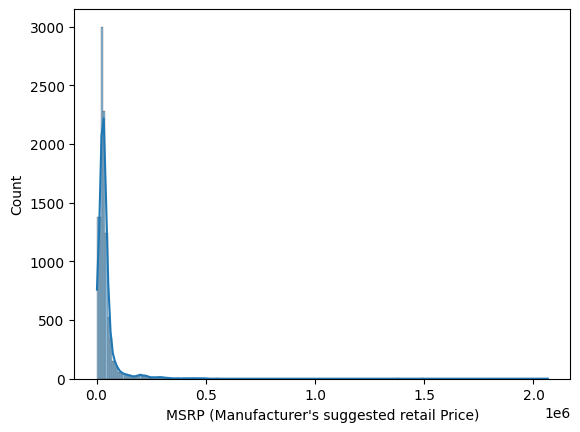

In [25]:
sns.histplot(df["MSRP (Manufacturer's suggested retail Price)"], kde=True)
plt.show()

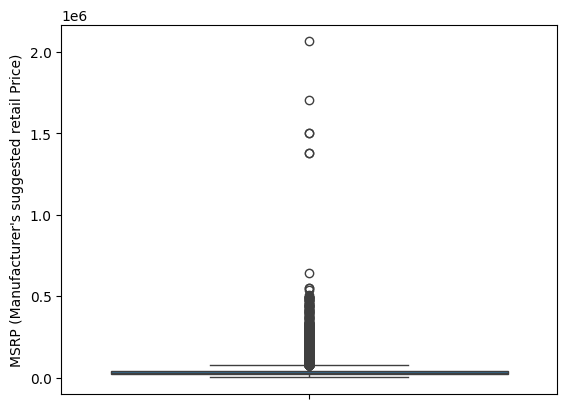

In [26]:
sns.boxplot(df["MSRP (Manufacturer's suggested retail Price)"])
plt.show()
            

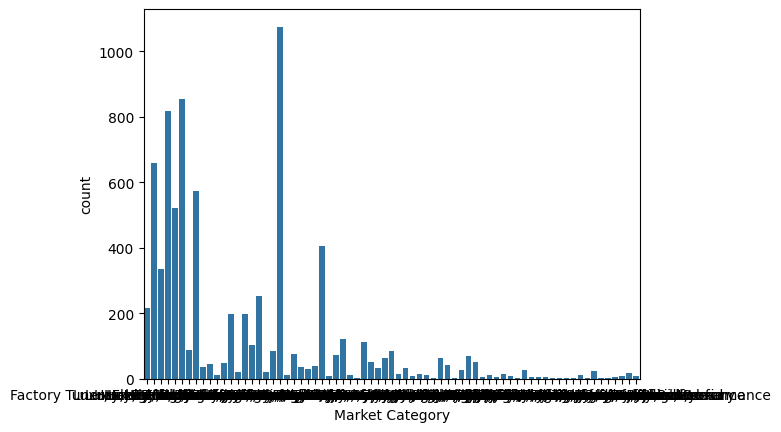

In [27]:
sns.countplot(x=df["Market Category"])
plt.show()

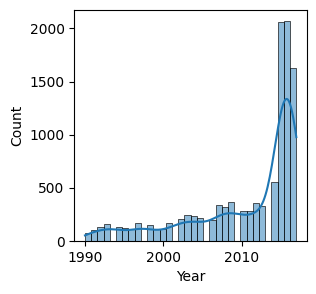

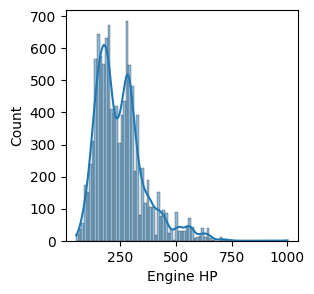

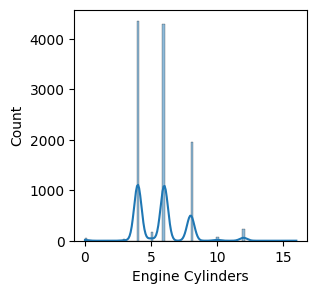

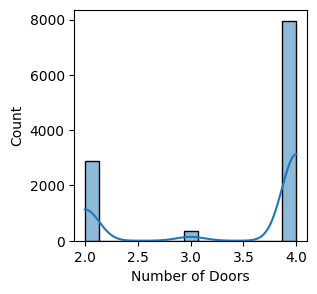

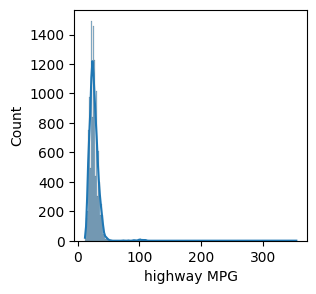

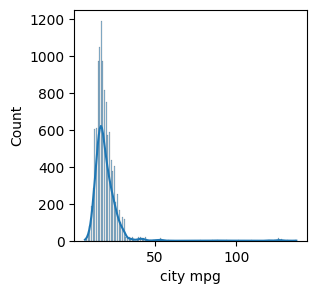

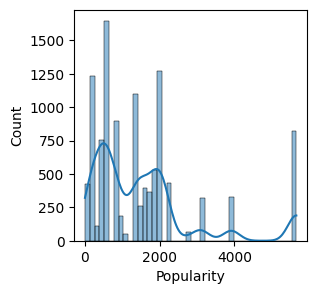

In [29]:
for cols in num_cols:
    plt.figure(figsize=(3,3))
    sns.histplot(df[cols], kde=True)
    plt.show()